In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2 as cv
from tqdm import tqdm
import matplotlib.pyplot as plt
from keras.applications.vgg16 import preprocess_input
import tensorflow.keras.layers as tfl
from sklearn import metrics

In [2]:
def loadData(dir_path):
    X = []
    y = []
    labels = dict()
    i = 0
    for path in tqdm(sorted(os.listdir(dir_path))): #traverse through directories under Train/Val/Test
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path+'\\'+path):
                if not file.startswith('.'):
                    img = cv.imread(dir_path+'\\'+path+'\\'+file)
                    X.append(img)
                    y.append(i)
            i=i+1
    X = np.array(X,dtype='object')
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X,y,labels


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  2.92it/s]


61 images loaded from ..\TRAIN_RE directory.


100%|██████████| 2/2 [00:00<00:00,  3.21it/s]


64 images loaded from ..\VAL_RE directory.


100%|██████████| 2/2 [00:00<00:00,  7.27it/s]


39 images loaded from ..\TEST_RE directory.


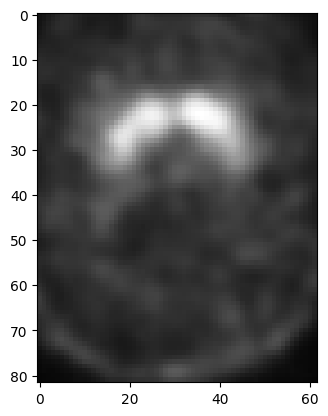

In [3]:
X_train, y_train, labels = loadData(r'..\TRAIN_RE')
X_val, y_val, _ = loadData(r'..\VAL_RE')
X_test, y_test, _ = loadData(r'..\TEST_RE')
IMG_SIZE = (64,64)
plt.imshow(X_train[0])
plt.show()

In [4]:
def preprocess_imgs(set, img_size):
    set_new = []
    for img in set:
        img = cv.resize(img, dsize=img_size, interpolation=cv.INTER_CUBIC)
        set_new.append(preprocess_input(img))
    return np.array(set_new)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


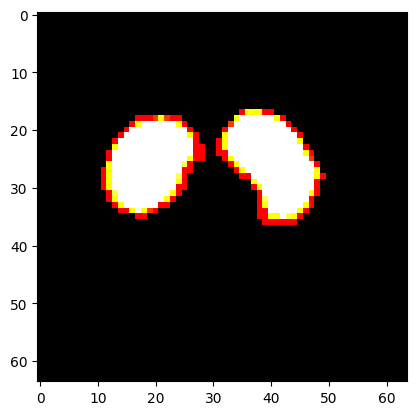

In [5]:
X_train_fin = preprocess_imgs(set=X_train,img_size=IMG_SIZE)
X_val_fin = preprocess_imgs(set=X_val,img_size=IMG_SIZE)
X_test_fin = preprocess_imgs(set=X_test,img_size=IMG_SIZE)
plt.imshow(X_test_fin[0])
plt.show()

In [6]:
model = tf.keras.Sequential([
        tfl.ZeroPadding2D(padding=(3,3), input_shape=(64,64,3)),
        tfl.Conv2D(filters = 32, strides = 1, kernel_size=(7,7)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Dropout(0.4),
        tfl.Conv2D(filters = 64, strides = 1, kernel_size=(5,5)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Dropout(0.4),
        tfl.MaxPool2D(),
        tfl.Flatten(),
        tfl.Dense(units = 1, activation = 'sigmoid')
    ])
model.layers[-7]._name = 'conv'
model.layers[-6]._name = 'final_norm'
model.layers[-5]._name = 'final_relu'
model.layers[-4]._name = 'final_drop'
model.layers[-3]._name = 'maxpool'
last_conv_layer_name = 'conv'
classifier_layer_names = [
    'final_norm',
    'final_relu',
    'final_drop',
    'maxpool',
]

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 zero_padding2d (ZeroPaddin  (None, 70, 70, 3)         0         
 g2D)                                                            
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        4736      
                                                                 
 batch_normalization (Batch  (None, 64, 64, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 64, 64, 32)        0         
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv (Conv2D)               (None, 60, 60, 64)        5

In [8]:
def plot_roc_curve(true_y, y_prob):

    fpr, tpr, thresholds = metrics.roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.title('ROC')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

In [9]:
model.compile(optimizer='nadam',loss='binary_crossentropy',metrics='accuracy')
mcp = tf.keras.callbacks.ModelCheckpoint(r'..\Checkpoints\nadam32_temp', monitor="val_accuracy", save_best_only=True, save_weights_only=False)
history = model.fit(X_train_fin,y_train,validation_data=(X_val_fin,y_val),epochs=30,batch_size=32, callbacks=[mcp])

Epoch 1/30
2/2 [==============================] - ETA: 0s - loss: 5.3691 - accuracy: 0.5738INFO:tensorflow:Assets written to: ..\Checkpoints\nadam32_temp\assets


INFO:tensorflow:Assets written to: ..\Checkpoints\nadam32_temp\assets


2/2 [==============================] - 6s 3s/step - loss: 5.3691 - accuracy: 0.5738 - val_loss: 0.4415 - val_accuracy: 0.8125
Epoch 2/30
2/2 [==============================] - 1s 356ms/step - loss: 2.8914 - accuracy: 0.6230 - val_loss: 1.4045 - val_accuracy: 0.6875
Epoch 3/30
2/2 [==============================] - 1s 368ms/step - loss: 2.9290 - accuracy: 0.7049 - val_loss: 7.0994 - val_accuracy: 0.4688
Epoch 4/30
2/2 [==============================] - 1s 390ms/step - loss: 0.8819 - accuracy: 0.8525 - val_loss: 12.4399 - val_accuracy: 0.3906
Epoch 5/30
2/2 [==============================] - 1s 381ms/step - loss: 0.8777 - accuracy: 0.8033 - val_loss: 8.9042 - val_accuracy: 0.4375
Epoch 6/30
2/2 [==============================] - 1s 411ms/step - loss: 1.1777 - accuracy: 0.7377 - val_loss: 11.1076 - val_accuracy: 0.3906
Epoch 7/30
2/2 [==============================] - 1s 375ms/step - loss: 0.2689 - accuracy: 0.9016 - val_loss: 11.3429 - val_accuracy: 0.3906
Epoch 8/30
2/2 [===============

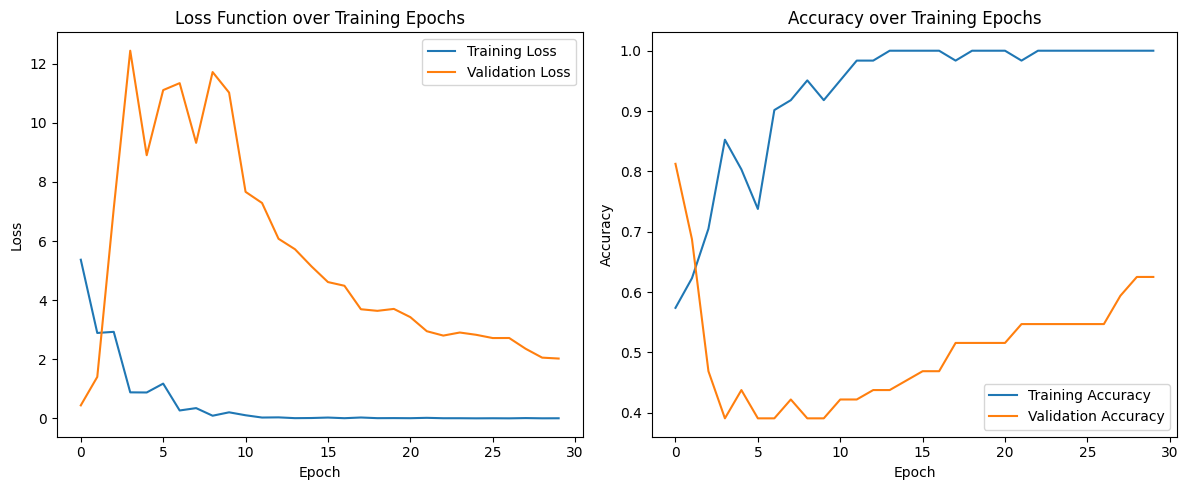

In [10]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the loss function graph
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Function over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# model.load_weights('../Checkpoints/nadam32_temp')

model.evaluate(X_val_fin,y_val)

2/2 [==============================] - 0s 49ms/step - loss: 2.0256 - accuracy: 0.6250


[2.025618314743042, 0.625]

In [12]:
model.evaluate(X_test_fin,y_test)

2/2 [==============================] - 0s 16ms/step - loss: 0.7168 - accuracy: 0.8462


[0.7167973518371582, 0.8461538553237915]

In [13]:
yhat_val = model.predict(X_val_fin)
yhat_val_fin = [1 if x>=0.5 else 0 for x in yhat_val]
yhat_test = model.predict(X_test_fin)
yhat_test_fin = [1 if x>=0.5 else 0 for x in yhat_test]


2/2 [==============================] - 0s 15ms/step


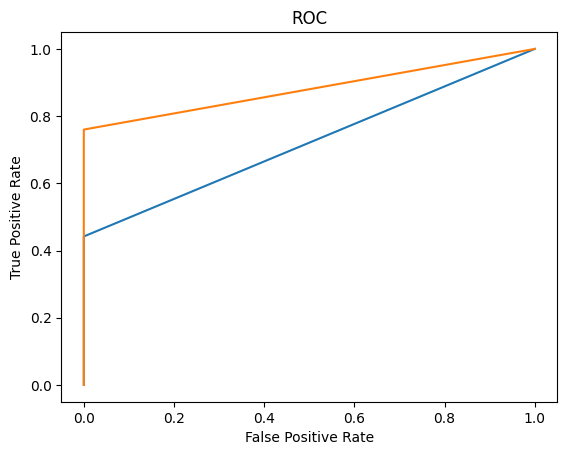

In [14]:
plot_roc_curve(y_val,yhat_val_fin)
plot_roc_curve(y_test,yhat_test_fin)

F1 measure: 0.6129032258064516
ROC AUC: 0.7209302325581395


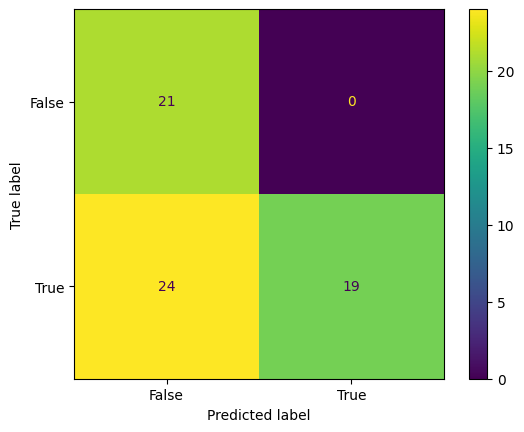

In [15]:
confusion_matrix_val = metrics.confusion_matrix(y_val,yhat_val_fin)
cmv = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_val, display_labels = [False, True])
# plot_roc_curve(y_val,yhat_val_fin)
print(f'F1 measure: {metrics.f1_score(y_val,yhat_val_fin)}\nROC AUC: {metrics.roc_auc_score(y_val,yhat_val_fin)}')
cmv.plot()
plt.show()

F1 measure: 0.8636363636363636
ROC AUC: 0.88


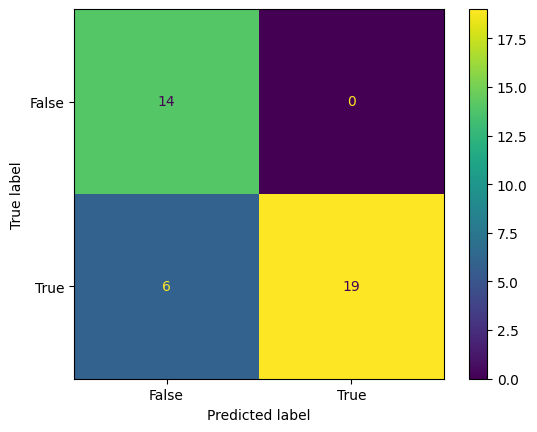

In [16]:
confusion_matrix_test = metrics.confusion_matrix(y_test,yhat_test_fin)
cmt = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test, display_labels = [False, True])
# plot_roc_curve(y_test,yhat_test_fin)
print(f'F1 measure: {metrics.f1_score(y_test,yhat_test_fin)}\nROC AUC: {metrics.roc_auc_score(y_test,yhat_test_fin)}')
cmt.plot()
plt.show()

In [29]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
i = 20
explainer = lime_image.LimeImageExplainer()
img = X_test_fin[i].astype(np.uint8)

In [30]:
explanation = explainer.explain_instance(img,model.predict,top_labels=2, hide_color = 0, num_samples = 250)

  0%|          | 0/250 [00:00<?, ?it/s]

1/1 [==============================] - 0s 38ms/step


  8%|▊         | 20/250 [00:00<00:01, 117.76it/s]

1/1 [==============================] - 0s 54ms/step


 16%|█▌        | 40/250 [00:00<00:01, 114.44it/s]

...

 88%|████████▊ | 220/250 [00:01<00:00, 117.21it/s]

1/1 [==============================] - 0s 43ms/step


 96%|█████████▌| 240/250 [00:02<00:00, 118.17it/s]

1/1 [==============================] - 0s 34ms/step


100%|██████████| 250/250 [00:02<00:00, 118.52it/s]


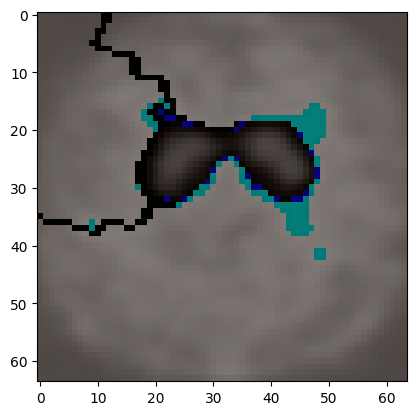

yhat:  0 
True:  1


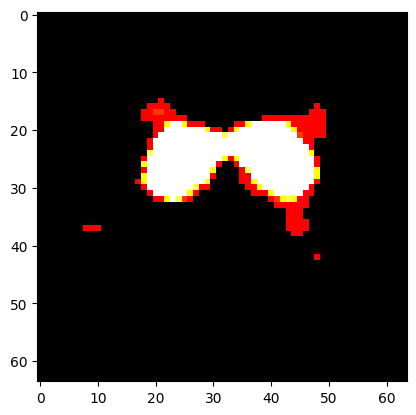

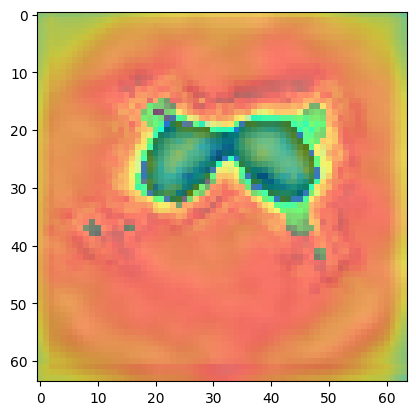

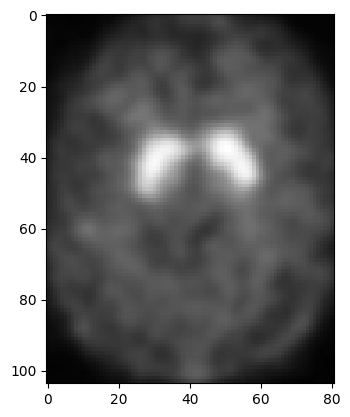

In [31]:
temp, mask = explanation.get_image_and_mask(0,positive_only = True, num_features=10, hide_rest = False)
plt.imshow(mark_boundaries(temp/2 + 0.5,mask).astype(np.uint8))  
plt.show() 
print("yhat: ",yhat_test_fin[i],"\nTrue: ",y_test[i])
plt.imshow(X_test_fin[i])
plt.show()
def gradcam_heatmap(img, model, last_conv_layer_name, classifier_layer_names):
    img = np.expand_dims(img, axis=0)
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    for layer_name in classifier_layer_names:
        x = model.get_layer(layer_name)(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        last_conv_layer_output = last_conv_layer_model(img)
        tape.watch(last_conv_layer_output)

        preds = classifier_model(last_conv_layer_output)
        # Reshape the preds tensor to match the shape of top_class_channel
        preds = tf.reshape(preds, (-1, preds.shape[-1]))

        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

        grads = tape.gradient(top_class_channel, last_conv_layer_output)

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        last_conv_layer_output = last_conv_layer_output.numpy()[0]
        pooled_grads = pooled_grads.numpy()

        for i in range(pooled_grads.shape[-1]):
            last_conv_layer_output[:, :, i] *= pooled_grads[i]

        heatmap = np.mean(last_conv_layer_output, axis=-1)
        heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

import matplotlib as mpl

heatmap = gradcam_heatmap(img, model, last_conv_layer_name, classifier_layer_names)
heatmap = np.uint8(heatmap*255)
jet = mpl.colormaps.get_cmap("jet")
jet_colours = jet(np.arange(256))[:,:3]
jet_heatmap = jet_colours[heatmap]

jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

superimposed_img = (jet_heatmap + img)
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
plt.imshow(superimposed_img)
plt.show()
plt.imshow(X_test[i])
plt.show()